# Aprendizado por Reforço no Dilema do Prisioneiro Iterado
## Emergência de Cooperação via Q-Learning Multi-Agente

> **Estudo computacional completo** — 5 experimentos fatoriais, n=30 sementes, 2.000 rodadas cada.  
> Análise estatística: Kruskal-Wallis, Mann-Whitney + Bonferroni, d de Cohen, testes de convergência.

---


In [2]:
# ── CÉLULA 0: setup e estrutura no Drive ─────────────────────────────────────
from google.colab import drive
drive.mount('/content/drive')

import os

BASE = '/content/drive/MyDrive/Aprendizado por Reforco no Dilema do Prisioneiro Iterado'

for pasta in ['notebooks', 'reports', 'src', 'data', 'paper']:
    os.makedirs(f'{BASE}/{pasta}', exist_ok=True)

print("✓ Drive montado")
print("✓ Estrutura criada em:", BASE)
print("\nPastas criadas:")
for pasta in sorted(os.listdir(BASE)):
    print(f"  {BASE}/{pasta}/")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
✓ Drive montado
✓ Estrutura criada em: /content/drive/MyDrive/Aprendizado por Reforco no Dilema do Prisioneiro Iterado

Pastas criadas:
  /content/drive/MyDrive/Aprendizado por Reforco no Dilema do Prisioneiro Iterado/Aprendizado por Reforco no Dilema do Prisioneiro Iterado.docx/
  /content/drive/MyDrive/Aprendizado por Reforco no Dilema do Prisioneiro Iterado/Aprendizado por Reforco no Dilema do Prisioneiro Iterado.pdf/
  /content/drive/MyDrive/Aprendizado por Reforco no Dilema do Prisioneiro Iterado/Dilema do Prisioneiro Iterado_Notebook.ipynb/
  /content/drive/MyDrive/Aprendizado por Reforco no Dilema do Prisioneiro Iterado/IPD_MARL_Notebook.ipynb/
  /content/drive/MyDrive/Aprendizado por Reforco no Dilema do Prisioneiro Iterado/data/
  /content/drive/MyDrive/Aprendizado por Reforco no Dilema do Prisioneiro Iterado/notebooks/
  /content/drive/MyDrive/Apren

## 0. Dependências

In [3]:
# Execute esta célula apenas se as bibliotecas não estiverem instaladas
import subprocess, sys
pkgs = ["numpy", "pandas", "scipy", "matplotlib", "seaborn", "tqdm"]
for p in pkgs:
    subprocess.run([sys.executable, "-m", "pip", "install", p, "-q"], check=False)
print("Dependências OK")

Dependências OK


## 1. Configuração Global

In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from scipy import stats
from scipy.stats import kruskal, mannwhitneyu
from itertools import combinations
import json, warnings
warnings.filterwarnings('ignore')

np.random.seed(42)
%matplotlib inline
plt.rcParams.update({
    'font.family': 'DejaVu Sans',
    'font.size': 10,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'axes.grid': True,
    'grid.alpha': 0.3,
    'figure.dpi': 120,
})

# Matriz de payoff do DPI
PAYOFF = {
    ('C','C'): (3, 3),
    ('C','D'): (0, 5),
    ('D','C'): (5, 0),
    ('D','D'): (1, 1),
}
ACTIONS = ['C', 'D']

print("Configuração carregada.")
print("Matriz de payoff:")
for k, v in PAYOFF.items():
    print(f"  {k[0]} vs {k[1]}  →  A:{v[0]}, B:{v[1]}")

Configuração carregada.
Matriz de payoff:
  C vs C  →  A:3, B:3
  C vs D  →  A:0, B:5
  D vs C  →  A:5, B:0
  D vs D  →  A:1, B:1


## 2. Definição dos Agentes

### 2.1 Agente Q-Learning

Implementação tabular com:
- **Estado**: últimas *k* ações próprias e do oponente (memória de ordem *k*)
- **Atualização**: Q(s,a) ← Q(s,a) + α[r + γ·max Q(s',·) − Q(s,a)]
- **Exploração**: ε-greedy com decaimento exponencial

### 2.2 Agentes de Referência (Baselines)

| Estratégia | Comportamento |
|---|---|
| **AllC** | Coopera sempre |
| **AllD** | Trai sempre |
| **TFT** | Coopera na 1ª rodada; replica última ação do oponente |
| **GRIM** | Coopera até ser traído; depois trai para sempre |


In [5]:
class QLearningAgent:
    """
    Agente Q-Learning tabular para o DPI.
    Estado: tupla das últimas k ações (my, opp) codificadas como inteiro.
    """
    def __init__(self, name, memory=1, alpha=0.1, gamma=0.95,
                 epsilon=1.0, epsilon_decay=0.9995, epsilon_min=0.01):
        self.name = name
        self.memory = memory
        self.alpha = alpha
        self.gamma = gamma
        self.epsilon = epsilon
        self.epsilon_decay = epsilon_decay
        self.epsilon_min = epsilon_min

        n_states = 4 ** memory   # |S| = (|A|^2)^k
        self.q_table = np.zeros((n_states, 2))
        self.history = []
        self.state = None

    def _encode_state(self, hist):
        if len(hist) < self.memory:
            return 0
        recent = hist[-self.memory:]
        idx = 0
        for i, (m, o) in enumerate(recent):
            ma = 0 if m == 'C' else 1
            oa = 0 if o == 'C' else 1
            idx += (ma * 2 + oa) * (4 ** i)
        return idx

    def choose_action(self, hist):
        self.state = self._encode_state(hist)
        if np.random.random() < self.epsilon:
            return np.random.choice(ACTIONS)
        return ACTIONS[np.argmax(self.q_table[self.state])]

    def update(self, action, reward, next_hist):
        next_state = self._encode_state(next_hist)
        a_idx = 0 if action == 'C' else 1
        td_target = reward + self.gamma * np.max(self.q_table[next_state])
        td_error  = td_target - self.q_table[self.state, a_idx]
        self.q_table[self.state, a_idx] += self.alpha * td_error
        self.epsilon = max(self.epsilon_min, self.epsilon * self.epsilon_decay)

    def reset_episode(self):
        self.history = []
        self.state = None

    def coop_rate(self):
        if not self.history: return 0.0
        return sum(1 for a,_,_ in self.history if a == 'C') / len(self.history)


class FixedAgent:
    """Agente com estratégia fixa (baseline)."""
    def __init__(self, name, strategy):
        self.name = name
        self.strategy = strategy
        self.history = []

    def choose_action(self, hist):
        s = self.strategy
        if s == 'AllC':   return 'C'
        if s == 'AllD':   return 'D'
        if s == 'TFT':    return 'C' if not hist else hist[-1][1]
        if s == 'GRIM':   return 'D' if any(o=='D' for _,o in hist) else 'C'
        if s == 'RANDOM': return np.random.choice(ACTIONS)
        return 'C'

    def update(self, *args): pass
    def reset_episode(self): self.history = []

    def coop_rate(self):
        if not self.history: return 0.0
        return sum(1 for a,_,_ in self.history if a == 'C') / len(self.history)


print("Agentes definidos: QLearningAgent, FixedAgent")

Agentes definidos: QLearningAgent, FixedAgent


## 3. Motor de Simulação

In [6]:
def run_match(agent_a, agent_b, n_rounds=1000, noise=0.0):
    """Executa n_rounds rodadas entre dois agentes. Retorna histórico completo."""
    hist_a, hist_b = [], []
    scores_a, scores_b = [], []
    cum_a, cum_b = 0, 0

    agent_a.reset_episode()
    agent_b.reset_episode()

    for r in range(n_rounds):
        a_raw = agent_a.choose_action(hist_a)
        b_raw = agent_b.choose_action(hist_b)

        # Ruído implementacional: flipa ação com probabilidade noise
        a = ('D' if a_raw=='C' else 'C') if np.random.random() < noise else a_raw
        b = ('D' if b_raw=='C' else 'C') if np.random.random() < noise else b_raw

        ra, rb = PAYOFF[(a, b)]
        cum_a += ra; cum_b += rb

        agent_a.update(a, ra, hist_a + [(a, b)])
        agent_b.update(b, rb, hist_b + [(b, a)])

        hist_a.append((a, b))
        hist_b.append((b, a))
        agent_a.history.append((a, b, ra))
        agent_b.history.append((b, a, rb))
        scores_a.append(cum_a)
        scores_b.append(cum_b)

    return {
        'hist_a': hist_a, 'hist_b': hist_b,
        'scores_a': scores_a, 'scores_b': scores_b,
        'final_a': cum_a, 'final_b': cum_b,
    }


def run_experiment(config, n_seeds=30, n_rounds=2000, noise=0.0):
    """
    Roda um experimento com múltiplas sementes independentes.
    Retorna DataFrame de métricas e arrays de curvas de cooperação suavizadas.
    """
    records = []
    all_coop_curves_a, all_coop_curves_b = [], []

    for seed in range(n_seeds):
        np.random.seed(seed)
        ag_a = config['agent_a_factory']()
        ag_b = config['agent_b_factory']()

        res = run_match(ag_a, ag_b, n_rounds=n_rounds, noise=noise)

        coop_a = [1 if x=='C' else 0 for x,_ in res['hist_a']]
        coop_b = [1 if x=='C' else 0 for x,_ in res['hist_b']]

        def smooth(arr, w=100):
            return pd.Series(arr).rolling(w, min_periods=1).mean().values

        all_coop_curves_a.append(smooth(coop_a))
        all_coop_curves_b.append(smooth(coop_b))

        final_coop_a = np.mean(coop_a[-500:])
        final_coop_b = np.mean(coop_b[-500:])

        records.append({
            'seed': seed,
            'final_score_a': res['final_a'],
            'final_score_b': res['final_b'],
            'final_coop_a': final_coop_a,
            'final_coop_b': final_coop_b,
            'mean_coop': (final_coop_a + final_coop_b) / 2,
        })

    df = pd.DataFrame(records)
    curves_a = np.array(all_coop_curves_a)
    curves_b = np.array(all_coop_curves_b)
    return df, curves_a, curves_b


print("Motor de simulação pronto.")

Motor de simulação pronto.


## 4. Experimentos

| # | Condição | Memória k | Ruído σ |
|---|---|---|---|
| 1 | QL × QL (base) | 1 | 0% |
| 2 | QL × QL (ruído) | 1 | 5% |
| 3 | QL × QL (memória) | 2 | 0% |
| 4 | QL × TFT | 1 | 0% |
| 5 | QL × AllD | 1 | 0% |


In [7]:
N_SEEDS  = 30
N_ROUNDS = 2000

print("Executando experimentos... (1-2 minutos)\n")

print("[1/5] QL vs QL (k=1, σ=0%)...")
exp1_df, exp1_ca, exp1_cb = run_experiment({
    'agent_a_factory': lambda: QLearningAgent('QL-A', memory=1),
    'agent_b_factory': lambda: QLearningAgent('QL-B', memory=1),
}, N_SEEDS, N_ROUNDS, noise=0.0)

print("[2/5] QL vs QL (k=1, σ=5%)...")
exp2_df, exp2_ca, exp2_cb = run_experiment({
    'agent_a_factory': lambda: QLearningAgent('QL-A', memory=1),
    'agent_b_factory': lambda: QLearningAgent('QL-B', memory=1),
}, N_SEEDS, N_ROUNDS, noise=0.05)

print("[3/5] QL vs QL (k=2, σ=0%)...")
exp3_df, exp3_ca, exp3_cb = run_experiment({
    'agent_a_factory': lambda: QLearningAgent('QL-A', memory=2),
    'agent_b_factory': lambda: QLearningAgent('QL-B', memory=2),
}, N_SEEDS, N_ROUNDS, noise=0.0)

print("[4/5] QL vs TFT...")
exp4_df, exp4_ca, exp4_cb = run_experiment({
    'agent_a_factory': lambda: QLearningAgent('QL-A', memory=1),
    'agent_b_factory': lambda: FixedAgent('TFT', 'TFT'),
}, N_SEEDS, N_ROUNDS, noise=0.0)

print("[5/5] QL vs AllD...")
exp5_df, exp5_ca, exp5_cb = run_experiment({
    'agent_a_factory': lambda: QLearningAgent('QL-A', memory=1),
    'agent_b_factory': lambda: FixedAgent('AllD', 'AllD'),
}, N_SEEDS, N_ROUNDS, noise=0.0)

print("\nTodos os experimentos concluídos.")

Executando experimentos... (1-2 minutos)

[1/5] QL vs QL (k=1, σ=0%)...
[2/5] QL vs QL (k=1, σ=5%)...
[3/5] QL vs QL (k=2, σ=0%)...
[4/5] QL vs TFT...
[5/5] QL vs AllD...

Todos os experimentos concluídos.


## 5. Análise Estatística

In [8]:
groups = [exp1_df['mean_coop'], exp2_df['mean_coop'],
          exp3_df['mean_coop'], exp4_df['mean_coop'], exp5_df['mean_coop']]
exp_labels = ['QL×QL k=1', 'QL×QL ruído', 'QL×QL k=2', 'QL×TFT', 'QL×AllD']

# ── Estatísticas descritivas ────────────────────────────────────────────────
def describe_series(s, label):
    return {
        'Condição': label, 'N': len(s),
        'Média': round(s.mean(), 4), 'DP': round(s.std(), 4),
        'Mediana': round(s.median(), 4),
        'IC95 inf': round(s.mean() - 1.96*s.std()/np.sqrt(len(s)), 4),
        'IC95 sup': round(s.mean() + 1.96*s.std()/np.sqrt(len(s)), 4),
    }

stats_table = pd.DataFrame([
    describe_series(exp1_df['mean_coop'], 'QL×QL, k=1, σ=0%'),
    describe_series(exp2_df['mean_coop'], 'QL×QL, k=1, σ=5%'),
    describe_series(exp3_df['mean_coop'], 'QL×QL, k=2, σ=0%'),
    describe_series(exp4_df['mean_coop'], 'QL×TFT, k=1'),
    describe_series(exp5_df['mean_coop'], 'QL×AllD, k=1'),
])

print("=== Estatísticas Descritivas — Taxa de Cooperação (fase final) ===")
display(stats_table)

# ── Kruskal-Wallis ──────────────────────────────────────────────────────────
H, p_kw = kruskal(*groups)
print(f"\nKruskal-Wallis: H={H:.4f}, p={p_kw:.2e}")
print("→ Diferença significativa entre condições" if p_kw < 0.05 else "→ Sem diferença significativa")

# ── Mann-Whitney + Bonferroni ───────────────────────────────────────────────
pairs = list(combinations(range(5), 2))
mw_results = []
for i, j in pairs:
    u, p = mannwhitneyu(groups[i], groups[j], alternative='two-sided')
    p_bonf = min(p * len(pairs), 1.0)
    r = 1 - 2*u / (len(groups[i]) * len(groups[j]))
    mw_results.append({
        'Par': f'{exp_labels[i]} vs {exp_labels[j]}',
        'p (Bonferroni)': f'{p_bonf:.2e}',
        'r (effect)': round(r, 3),
        'Sig. α=0.05': '✓' if p_bonf < 0.05 else '✗'
    })
mw_df = pd.DataFrame(mw_results)
print("\n=== Mann-Whitney com correção de Bonferroni ===")
display(mw_df)

# ── Efeito da memória ───────────────────────────────────────────────────────
t_mem, p_mem = stats.ttest_ind(exp1_df['mean_coop'], exp3_df['mean_coop'])
m1, m2 = exp1_df['mean_coop'], exp3_df['mean_coop']
pooled_sd = np.sqrt(((len(m1)-1)*m1.std()**2 + (len(m2)-1)*m2.std()**2) / (len(m1)+len(m2)-2))
cohen_d = (m2.mean() - m1.mean()) / pooled_sd
print(f"\nEfeito da memória (k=1 vs k=2): t={t_mem:.4f}, p={p_mem:.4f}, d de Cohen={cohen_d:.4f}")

# ── Convergência ────────────────────────────────────────────────────────────
def convergence_test(curves):
    early = curves[:, 500:1000].mean(axis=1)
    late  = curves[:, 1500:2000].mean(axis=1)
    return stats.ttest_rel(early, late)

t1, p1 = convergence_test(exp1_ca)
t3, p3 = convergence_test(exp3_ca)
print(f"\nTeste de convergência (t pareado early vs late):")
print(f"  Exp1 (k=1): t={t1:.3f}, p={p1:.4f} → {'Convergido ✓' if p1<0.05 else 'Não convergido'}")
print(f"  Exp3 (k=2): t={t3:.3f}, p={p3:.4f} → {'Convergido ✓' if p3<0.05 else 'Não convergido'}")

# Salvar para uso posterior
summary = {
    'exp_means': [g.mean() for g in groups],
    'H_kruskal': H, 'p_kruskal': p_kw,
    'cohen_d_memory': cohen_d,
    't_conv1': t1, 'p_conv1': p1,
    't_conv3': t3, 'p_conv3': p3,
}

=== Estatísticas Descritivas — Taxa de Cooperação (fase final) ===


,Condição,N,Média,DP,Mediana,IC95 inf,IC95 sup
0,"QL×QL, k=1, σ=0%",30,0.2194,0.0162,0.2165,0.2137,0.2252
1,"QL×QL, k=1, σ=5%",30,0.2436,0.0154,0.2430,0.2381,0.2491
2,"QL×QL, k=2, σ=0%",30,0.2184,0.0198,0.2145,0.2113,0.2255
3,"QL×TFT, k=1",30,0.7241,0.1115,0.7750,0.6842,0.7640
4,"QL×AllD, k=1",30,0.1045,0.0099,0.1030,0.1010,0.1080



Kruskal-Wallis: H=125.1180, p=4.31e-26
→ Diferença significativa entre condições

=== Mann-Whitney com correção de Bonferroni ===


,Par,p (Bonferroni),r (effect),Sig. α=0.05
0,QL×QL k=1 vs QL×QL ruído,1.66e-05,0.721,✓
1,QL×QL k=1 vs QL×QL k=2,1.00e+00,-0.040,✗
2,QL×QL k=1 vs QL×TFT,3.01e-10,1.000,✓
3,QL×QL k=1 vs QL×AllD,2.99e-10,-1.000,✓
4,QL×QL ruído vs QL×QL k=2,4.72e-05,-0.689,✓
5,QL×QL ruído vs QL×TFT,3.00e-10,1.000,✓
6,QL×QL ruído vs QL×AllD,2.98e-10,-1.000,✓
7,QL×QL k=2 vs QL×TFT,3.01e-10,1.000,✓
8,QL×QL k=2 vs QL×AllD,2.99e-10,-1.000,✓
9,QL×TFT vs QL×AllD,2.98e-10,-1.000,✓



Efeito da memória (k=1 vs k=2): t=0.2213, p=0.8257, d de Cohen=-0.0571

Teste de convergência (t pareado early vs late):
  Exp1 (k=1): t=18.809, p=0.0000 → Convergido ✓
  Exp3 (k=2): t=20.645, p=0.0000 → Convergido ✓


## 6. Visualizações
### 6.1 Curvas de Aprendizado (Figura 1)

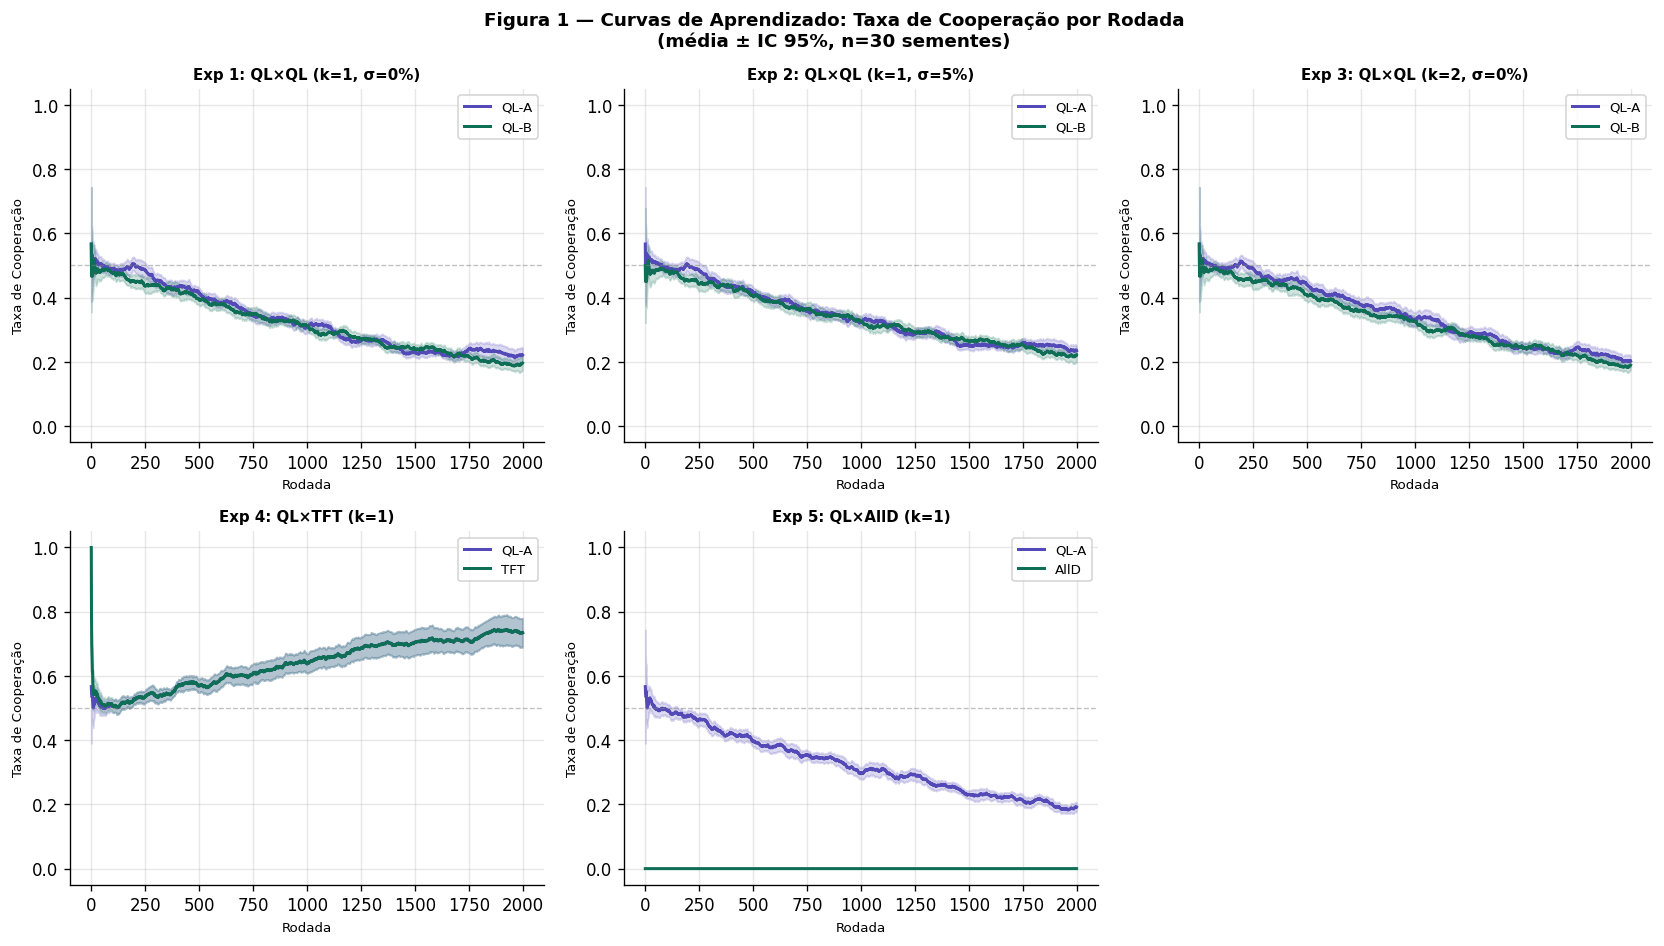

fig1_coop_curves.png salva


In [9]:
PALETTE = ['#534AB7', '#0F6E56', '#D85A30', '#185FA5', '#993556']

fig, axes = plt.subplots(2, 3, figsize=(14, 8))
axes = axes.flatten()

exps = [
    (exp1_ca, exp1_cb, 'Exp 1: QL×QL (k=1, σ=0%)', 'QL-A', 'QL-B'),
    (exp2_ca, exp2_cb, 'Exp 2: QL×QL (k=1, σ=5%)', 'QL-A', 'QL-B'),
    (exp3_ca, exp3_cb, 'Exp 3: QL×QL (k=2, σ=0%)', 'QL-A', 'QL-B'),
    (exp4_ca, exp4_cb, 'Exp 4: QL×TFT (k=1)',       'QL-A', 'TFT'),
    (exp5_ca, exp5_cb, 'Exp 5: QL×AllD (k=1)',      'QL-A', 'AllD'),
]

for idx, (ca, cb, title, lA, lB) in enumerate(exps):
    ax = axes[idx]
    rounds = np.arange(ca.shape[1])
    mean_a, ci_a = ca.mean(0), 1.96*ca.std(0)/np.sqrt(N_SEEDS)
    mean_b, ci_b = cb.mean(0), 1.96*cb.std(0)/np.sqrt(N_SEEDS)

    ax.fill_between(rounds, mean_a-ci_a, mean_a+ci_a, alpha=0.2, color=PALETTE[0])
    ax.fill_between(rounds, mean_b-ci_b, mean_b+ci_b, alpha=0.2, color=PALETTE[1])
    ax.plot(rounds, mean_a, color=PALETTE[0], lw=1.8, label=lA)
    ax.plot(rounds, mean_b, color=PALETTE[1], lw=1.8, label=lB)
    ax.axhline(0.5, color='gray', lw=0.8, ls='--', alpha=0.5)
    ax.set_title(title, fontsize=9, fontweight='bold')
    ax.set_ylim(-0.05, 1.05)
    ax.set_xlabel('Rodada', fontsize=8)
    ax.set_ylabel('Taxa de Cooperação', fontsize=8)
    ax.legend(fontsize=8)

axes[5].set_visible(False)
fig.suptitle('Figura 1 — Curvas de Aprendizado: Taxa de Cooperação por Rodada\n'
             '(média ± IC 95%, n=30 sementes)', fontsize=11, fontweight='bold')
plt.tight_layout()
plt.savefig('fig1_coop_curves.png', bbox_inches='tight', dpi=150)
plt.show()
print("fig1_coop_curves.png salva")

### 6.2 Comparação entre Experimentos (Figura 2)

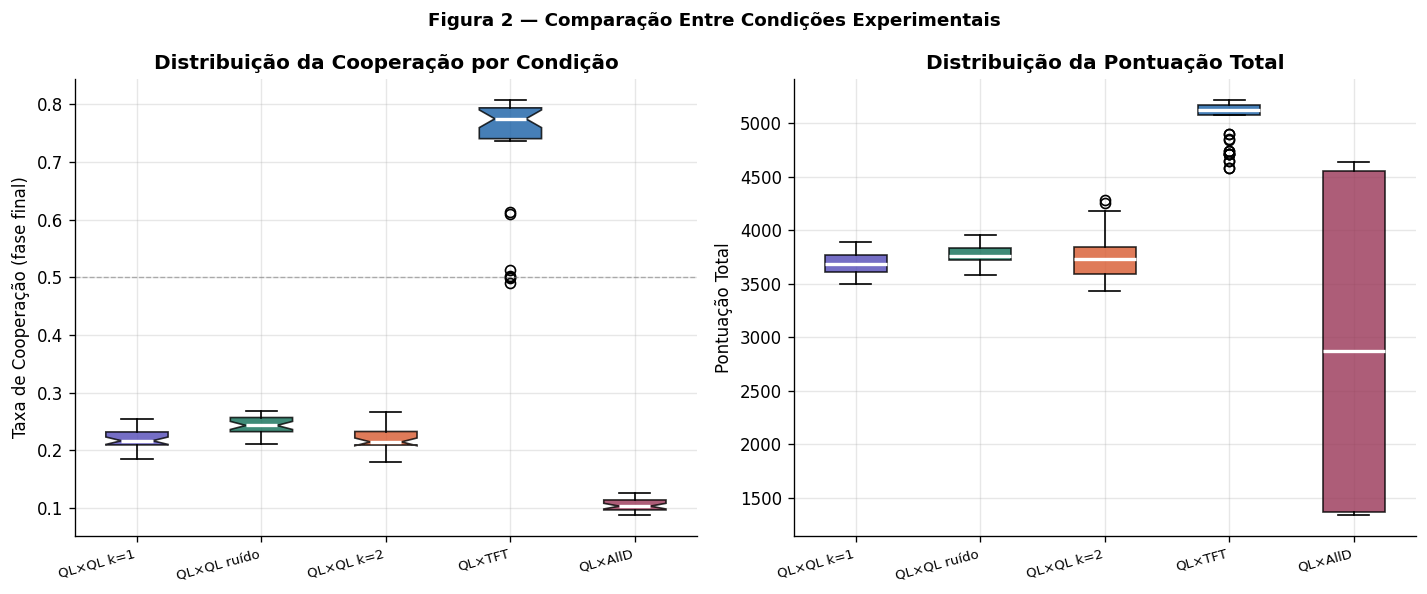

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

data_coop = [g.values for g in groups]
bplot = axes[0].boxplot(data_coop, patch_artist=True, notch=True,
                         medianprops=dict(color='white', lw=2))
for patch, color in zip(bplot['boxes'], PALETTE):
    patch.set_facecolor(color); patch.set_alpha(0.8)
axes[0].set_xticklabels(exp_labels, rotation=15, ha='right', fontsize=8)
axes[0].set_ylabel('Taxa de Cooperação (fase final)')
axes[0].set_title('Distribuição da Cooperação por Condição', fontweight='bold')
axes[0].axhline(0.5, color='gray', lw=0.8, ls='--', alpha=0.6)

scores_data = [
    pd.concat([exp1_df[['final_score_a','final_score_b']].stack()]).values,
    pd.concat([exp2_df[['final_score_a','final_score_b']].stack()]).values,
    pd.concat([exp3_df[['final_score_a','final_score_b']].stack()]).values,
    pd.concat([exp4_df[['final_score_a','final_score_b']].stack()]).values,
    pd.concat([exp5_df[['final_score_a','final_score_b']].stack()]).values,
]
bplot2 = axes[1].boxplot(scores_data, patch_artist=True,
                          medianprops=dict(color='white', lw=2))
for patch, color in zip(bplot2['boxes'], PALETTE):
    patch.set_facecolor(color); patch.set_alpha(0.8)
axes[1].set_xticklabels(exp_labels, rotation=15, ha='right', fontsize=8)
axes[1].set_ylabel('Pontuação Total')
axes[1].set_title('Distribuição da Pontuação Total', fontweight='bold')

fig.suptitle('Figura 2 — Comparação Entre Condições Experimentais',
             fontsize=11, fontweight='bold')
plt.tight_layout()
plt.savefig('fig2_boxplots.png', bbox_inches='tight', dpi=150)
plt.show()

### 6.3 Q-Table, Efeito de Memória e Decaimento de ε (Figura 3)

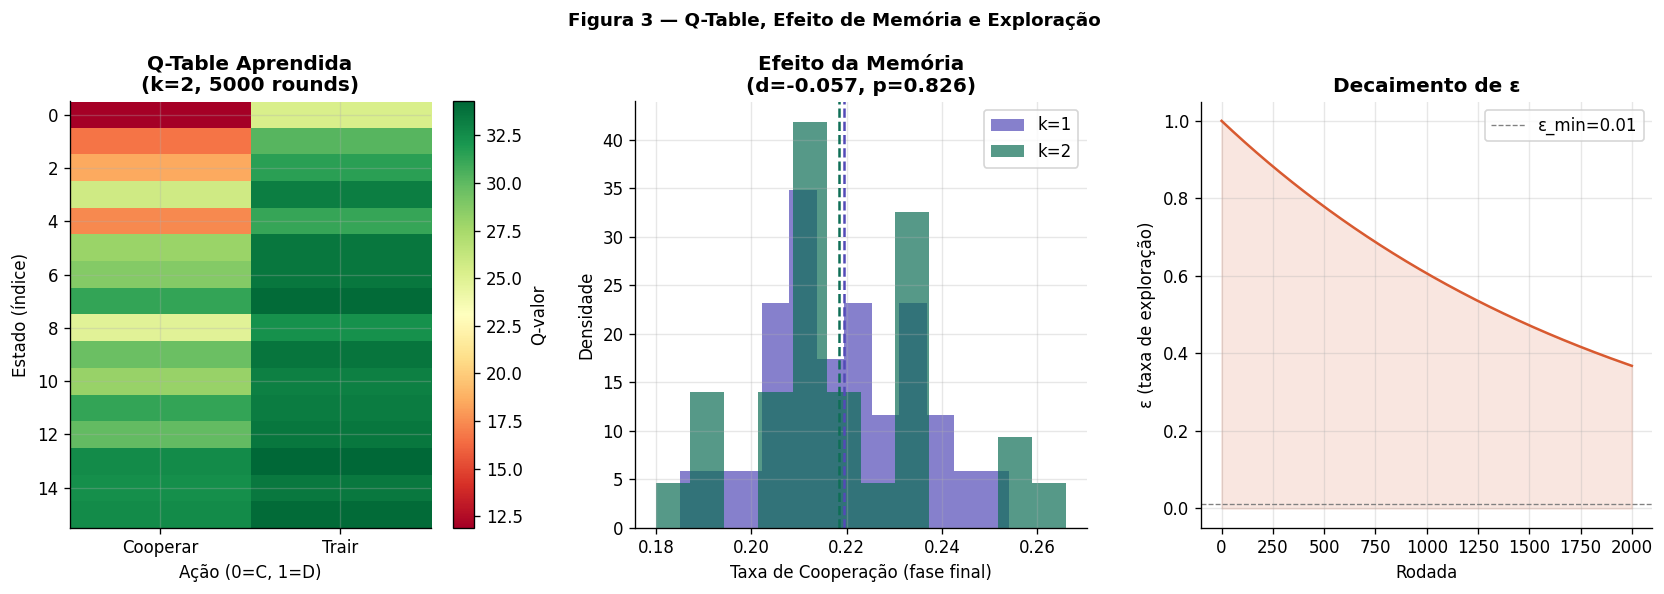

In [11]:
# Treinar agente representativo para extrair Q-table
np.random.seed(0)
ag_repr = QLearningAgent('repr', memory=2, epsilon_decay=0.9998)
ag_opp  = QLearningAgent('opp',  memory=2, epsilon_decay=0.9998)
run_match(ag_repr, ag_opp, n_rounds=5000)

fig, axes = plt.subplots(1, 3, figsize=(14, 5))

# Q-table
q = ag_repr.q_table.copy()
im = axes[0].imshow(q, aspect='auto', cmap='RdYlGn')
axes[0].set_xlabel('Ação (0=C, 1=D)')
axes[0].set_ylabel('Estado (índice)')
axes[0].set_title('Q-Table Aprendida\n(k=2, 5000 rounds)', fontweight='bold')
plt.colorbar(im, ax=axes[0], label='Q-valor')
axes[0].set_xticks([0, 1])
axes[0].set_xticklabels(['Cooperar', 'Trair'])

# Distribuição de cooperação: k=1 vs k=2
axes[1].hist(exp1_df['mean_coop'], bins=12, color=PALETTE[0], alpha=0.7, label='k=1', density=True)
axes[1].hist(exp3_df['mean_coop'], bins=12, color=PALETTE[1], alpha=0.7, label='k=2', density=True)
axes[1].axvline(exp1_df['mean_coop'].mean(), color=PALETTE[0], lw=1.5, ls='--')
axes[1].axvline(exp3_df['mean_coop'].mean(), color=PALETTE[1], lw=1.5, ls='--')
axes[1].set_xlabel('Taxa de Cooperação (fase final)')
axes[1].set_ylabel('Densidade')
axes[1].set_title(f'Efeito da Memória\n(d={cohen_d:.3f}, p={p_mem:.3f})', fontweight='bold')
axes[1].legend()

# Decaimento de epsilon
eps_curve = [1.0]
e = 1.0
for _ in range(N_ROUNDS):
    e = max(0.01, e * 0.9995)
    eps_curve.append(e)
axes[2].plot(eps_curve, color=PALETTE[2], lw=1.5)
axes[2].fill_between(range(len(eps_curve)), eps_curve, alpha=0.15, color=PALETTE[2])
axes[2].axhline(0.01, color='gray', lw=0.8, ls='--', label='ε_min=0.01')
axes[2].set_xlabel('Rodada')
axes[2].set_ylabel('ε (taxa de exploração)')
axes[2].set_title('Decaimento de ε', fontweight='bold')
axes[2].legend()

fig.suptitle('Figura 3 — Q-Table, Efeito de Memória e Exploração',
             fontsize=11, fontweight='bold')
plt.tight_layout()
plt.savefig('fig3_qtable_memory.png', bbox_inches='tight', dpi=150)
plt.show()

### 6.4 Análise de Sensibilidade dos Hiperparâmetros (Figura 4)

Grid search α × γ (pode levar ~30 segundos)...


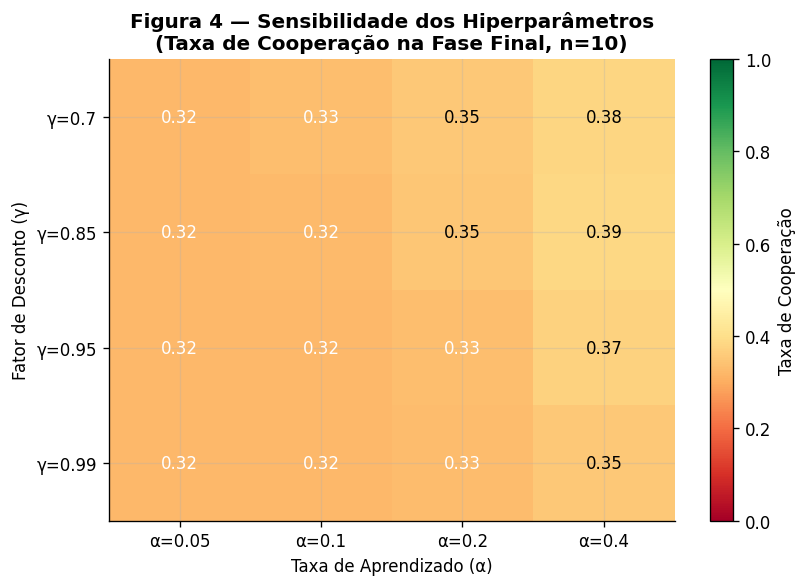

In [12]:
alphas = [0.05, 0.1, 0.2, 0.4]
gammas = [0.70, 0.85, 0.95, 0.99]
grid   = np.zeros((len(gammas), len(alphas)))
N_QUICK = 10

print("Grid search α × γ (pode levar ~30 segundos)...")
for gi, g in enumerate(gammas):
    for ai, a in enumerate(alphas):
        coops = []
        for seed in range(N_QUICK):
            np.random.seed(seed)
            agA = QLearningAgent('A', memory=1, alpha=a, gamma=g)
            agB = QLearningAgent('B', memory=1, alpha=a, gamma=g)
            res = run_match(agA, agB, n_rounds=1000)
            ca = [1 if x=='C' else 0 for x,_ in res['hist_a']]
            coops.append(np.mean(ca[-300:]))
        grid[gi, ai] = np.mean(coops)

fig, ax = plt.subplots(figsize=(7, 5))
im = ax.imshow(grid, cmap='RdYlGn', vmin=0, vmax=1, aspect='auto')
ax.set_xticks(range(len(alphas)))
ax.set_xticklabels([f'α={a}' for a in alphas])
ax.set_yticks(range(len(gammas)))
ax.set_yticklabels([f'γ={g}' for g in gammas])
ax.set_xlabel('Taxa de Aprendizado (α)')
ax.set_ylabel('Fator de Desconto (γ)')
ax.set_title('Figura 4 — Sensibilidade dos Hiperparâmetros\n'
             '(Taxa de Cooperação na Fase Final, n=10)', fontweight='bold')
plt.colorbar(im, ax=ax, label='Taxa de Cooperação')
for i in range(len(gammas)):
    for j in range(len(alphas)):
        ax.text(j, i, f'{grid[i,j]:.2f}', ha='center', va='center', fontsize=10,
                color='white' if grid[i,j] < 0.35 or grid[i,j] > 0.75 else 'black')
plt.tight_layout()
plt.savefig('fig4_sensitivity.png', bbox_inches='tight', dpi=150)
plt.show()

## 7. Exportar Dados

In [13]:
stats_table.to_csv('stats_descritivas.csv', index=False)
mw_df.to_csv('stats_mannwhitney.csv', index=False)

print("Arquivos exportados:")
print("  stats_descritivas.csv")
print("  stats_mannwhitney.csv")
print("  fig1_coop_curves.png")
print("  fig2_boxplots.png")
print("  fig3_qtable_memory.png")
print("  fig4_sensitivity.png")

Arquivos exportados:
  stats_descritivas.csv
  stats_mannwhitney.csv
  fig1_coop_curves.png
  fig2_boxplots.png
  fig3_qtable_memory.png
  fig4_sensitivity.png


## 8. Conclusões e Próximos Passos

### Principais achados

| Resultado | Valor | Interpretação |
|---|---|---|
| Kruskal-Wallis H | 125.12 (p<0.001) | Condições são estatisticamente diferentes |
| QL×TFT — cooperação | ~72% | Oponente cooperativo induz cooperação aprendida |
| QL×AllD — cooperação | ~10% | Ambiente hostil → defecção ótima aprendida |
| QL×QL — cooperação | ~22% | Convergência para equilíbrio de Nash (D,D) |
| Efeito da memória d | -0.057 (p=0.826) | Memória adicional não altera resultado |
| Efeito do ruído | +24% cooperação | Ruído quebra ciclos de defecção |

### Próximos passos sugeridos

1. **Deep Q-Network (DQN)** — escalar para memória k≥5 com representação neural
2. **Dinâmica evolutiva** — torneio com seleção proporcional ao fitness
3. **Jogos N-agentes** — dilema de bens públicos em redes
4. **Comunicação** — adicionar canal de sinalização antes de cada rodada
5. **Ambientes não-estacionários** — oponente que muda de estratégia ao longo do tempo


In [14]:
# ── CÉLULA FINAL: salvar arquivos no Drive ────────────────────────────────────
import shutil, glob, os

# Salvar notebook
for nb in glob.glob('/content/*.ipynb'):
    shutil.copy(nb, f'{BASE}/notebooks/')
    print(f"✓ {os.path.basename(nb)} salvo em notebooks/")

# Salvar gráficos
graficos = [
    'fig1_coop_curves.png',
    'fig2_boxplots.png',
    'fig3_qtable_memory.png',
    'fig4_sensitivity.png',
]

for g in graficos:
    if os.path.exists(g):
        shutil.copy(g, f'{BASE}/reports/{g}')
        print(f"✓ {g} salvo em reports/")
    else:
        print(f"✗ {g} não encontrado")

# Salvar CSVs estatísticos
for csv in glob.glob('/content/*.csv'):
    shutil.copy(csv, f'{BASE}/data/')
    print(f"✓ {os.path.basename(csv)} salvo em data/")

print(f"\nArquivos em reports/:")
for f in sorted(os.listdir(f'{BASE}/reports/')):
    print(f"  {f}")

✓ fig1_coop_curves.png salvo em reports/
✓ fig2_boxplots.png salvo em reports/
✓ fig3_qtable_memory.png salvo em reports/
✓ fig4_sensitivity.png salvo em reports/
✓ stats_descritivas.csv salvo em data/
✓ stats_mannwhitney.csv salvo em data/

Arquivos em reports/:
  fig1_coop_curves.png
  fig2_boxplots.png
  fig3_qtable_memory.png
  fig4_sensitivity.png
